# Local error distribution – comparative study (inside Ω)

This notebook runs a **comparative study of the pointwise solution error** inside the physical domain $\Omega$ for several `FEM.FUNCTION_CASE` test problems.

We compare:
- different **testcases** (each requires a different geometry model / SDF),
- different **B-spline orders** `p=q`,
- different **element sizes** via the number of divisions,
- and **boundary-element subdivision depth** via `FEM.MAX_SUBDIVISION ∈ {0, 2}`.

The main output is a set of **error heatmaps** (local distribution), plus summary metrics computed over points inside $\Omega$ only.

Notes:
- Assembly uses `mesh.TRANSFORM` (default: Höllig weight). The error evaluation below uses the same transformed weight for reconstruction.
- Runs can take a few minutes depending on the experiment grid. Reduce `EXPERIMENTS` or `HEATMAP_N` if needed.

In [1]:
# --- Imports / setup ---
import time
import math
import numpy as np
import torch
from scipy import sparse
from bspline import Bspline
import matplotlib.pyplot as plt

import FEM
import FEM_WEB
import mesh
import Geomertry

# Use float64 everywhere (matches solver defaults)
torch.set_default_dtype(torch.float64)
np.set_printoptions(precision=4, suppress=True)

# Optional: nicer plots
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("mesh.TRANSFORM =", mesh.TRANSFORM)
print("Default FEM.FUNCTION_CASE =", FEM.FUNCTION_CASE)

mesh.TRANSFORM = hollig
Default FEM.FUNCTION_CASE = 5


In [2]:
# --- Quick toggle ---
# Set SMOKE=True for a fast end-to-end check (1 run, lower resolution).
# Set SMOKE=False for the full comparative study.
SMOKE = False

In [ ]:
# --- Experiment configuration ---

def get_model_for_case(function_case: int):
    """Return an analytic geometry model compatible with the chosen FEM.FUNCTION_CASE."""
    if function_case == 0:
        # Disc example on [0,1]^2 (matches FEM.get_domain_for_case(0))
        return Geomertry.AnaliticalDistanceDisc_WEB(), "AnaliticalDistanceDisc_WEB"
    if 1 <= function_case <= 4:
        # Circle on [-1,1]^2
        return Geomertry.AnaliticalDistanceCircle(), "AnaliticalDistanceCircle"
    if function_case == 5:
        # L-shape on [-1,1]^2
        return Geomertry.AnaliticalDistanceLshape(), "AnaliticalDistanceLshape"
    if function_case == 9:
        # Triangle on [-1,1]^2
        return Geomertry.AnaliticalDistanceTriangle_RFunction(smoothness=0.1, preserve_zero_line=True), "AnaliticalDistanceTriangle_RFunction"
    if function_case == 10:
        # Regular pentagon on [-1,1]^2
        return Geomertry.AnaliticalDistancePentagon_RFunction(smoothness=0.1, preserve_zero_line=True), "AnaliticalDistancePentagon_RFunction"
    if function_case == 8:
        # Web-spline analytic example (ellipse-like * polynomial), on [-4,4]x[-3,3]
        return Geomertry.AnaliticalDistance_CASE8(), "AnaliticalDistance_CASE8"
    raise NotImplementedError(f"No analytic model mapping defined for FUNCTION_CASE={function_case}")


# Toggle for a quick execution check (keeps the notebook usable)
SMOKE = globals().get("SMOKE", False)

# Choose testcases (each needs a compatible model)
# 0 uses a different domain ([0,1]^2) and a different analytic model than the [-1,1]^2 cases.
CASES = [0, 1, 2, 5, 8, 9, 10]  # disc_WEB, circle, L-shape, CASE8, triangle, pentagon

# Compare multiple orders and element sizes
ORDER_DIV_PAIRS = [
    (2, 50),  # (order p=q, divisions)
    (3, 50),
    (2, 80),
 ]

# Compare boundary subdivision depth
MAX_SUBDIV_VALUES = [0, 2, 4]  # requested: FEM.MAX_SUBDIVISION = 0 vs 2

# Reconstruction / plotting resolution
HEATMAP_N = 160  # points per axis for local error maps
DELTA_SIM = 0.005  # mesh padding around FEM.DOMAIN

if SMOKE:
    CASES = [1]
    ORDER_DIV_PAIRS = [(2, 12)]
    MAX_SUBDIV_VALUES = [0]
    HEATMAP_N = 80
    print("SMOKE=True: running a minimal configuration")

print("Planned runs:")
n_runs = len(CASES) * len(ORDER_DIV_PAIRS) * len(MAX_SUBDIV_VALUES)
print("  cases:", CASES)
print("  (order,div):", ORDER_DIV_PAIRS)
print("  MAX_SUBDIVISION:", MAX_SUBDIV_VALUES)
print("  total runs:", n_runs)

Planned runs:
  cases: [0, 1, 2, 5, 8]
  (order,div): [(2, 50), (3, 50), (2, 80)]
  MAX_SUBDIVISION: [0, 2, 4]
  total runs: 45


In [4]:
# --- Core helpers: assemble/solve + vectorized local error field ---

NP_DTYPE = np.float64
TORCH_DTYPE = torch.float64


def assemble_and_solve_standard(*, model, function_case: int, divisions: int, order: int, max_subdivision: int, delta_sim: float):
    """Assemble a standard weighted B-spline system, then apply the WEB coupling-matrix transform (Eq. 8.9) and solve.

    This replaces the classical solve (FEM.solveWeak) by the WEB-transform pipeline:
      1) Assemble full K,F with FEM.processAllElements (same quadrature/assembly as classical)
      2) Reduce via FEM_WEB.transformStandardSystemToWEB (Höllig coupling matrix)
      3) Solve reduced system with FEM_WEB.solveWEB
      4) Convert back to equivalent full-basis coefficients for fast vectorized field evaluation

    Returns: dict with solution + mesh meta.
    """
    FEM.set_function_case(function_case)
    FEM.MAX_SUBDIVISION = int(max_subdivision)

    # Some scripts refer to FEM.MAX_SUBDIV; keep an alias for interactive work
    FEM.MAX_SUBDIV = FEM.MAX_SUBDIVISION

    default = mesh.getDefaultValues(div=divisions, order=order, delta=delta_sim)
    x0, y0, x1, y1, xDivision, yDivision, p, q = default
    knot_u, knot_w, weights, ctrlpts = mesh.generateRectangularMesh(*default)

    assert p == q
    assert xDivision == yDivision

    matrix_size = (xDivision + p + 1) * (yDivision + q + 1)
    K_full = sparse.lil_matrix((matrix_size, matrix_size), dtype=NP_DTYPE)
    F_full = np.zeros(matrix_size, dtype=NP_DTYPE)

    t0 = time.time()
    K_full, F_full, etype_std = FEM.processAllElements(model, p, q, knot_u, knot_w, xDivision, yDivision, K_full, F_full)
    t_asm = time.time() - t0

    # WEB coupling-matrix transform (Eq. 8.9)
    t0 = time.time()
    K_red, F_red, etype_web, bspline_classification, extended_basis, E_tilde = FEM_WEB.transformStandardSystemToWEB(
        K_full,
        F_full,
        model,
        p,
        q,
        knot_u,
        knot_w,
        xDivision,
        yDivision,
        extension_method="collocation",
        web_use_weight_normalization=True,
        web_ref_weight_eps=1e-6,
    )
    t_transform = time.time() - t0

    # Solve reduced WEB system
    t0 = time.time()
    u_reduced = FEM_WEB.solveWEB(K_red, F_red)
    t_solve = time.time() - t0

    # Convert reduced WEB coefficients to equivalent full-basis coefficients: u_full = E_tilde^T u_reduced
    u_full = (E_tilde.T @ np.asarray(u_reduced, dtype=NP_DTYPE)).astype(NP_DTYPE, copy=False)

    return {
        "function_case": int(function_case),
        "divisions": int(divisions),
        "order": int(order),
        "p": int(p),
        "q": int(q),
        "max_subdivision": int(max_subdivision),
        "knot_u": knot_u,
        "knot_w": knot_w,
        "xDivision": int(xDivision),
        "yDivision": int(yDivision),
        # Full-basis coefficients (for fast evaluation on grids)
        "u": u_full,
        # Reduced WEB coefficients + reconstruction metadata (for debugging / optional pointwise checks)
        "u_reduced": np.asarray(u_reduced, dtype=NP_DTYPE),
        "E_tilde": E_tilde,
        "bspline_classification": bspline_classification,
        "extended_basis": extended_basis,
        "etype": etype_web,
        "etype_std": etype_std,
        "t_assembly_s": float(t_asm),
        "t_transform_s": float(t_transform),
        "t_solve_s": float(t_solve),
    }


def compute_local_error_field_standard(*, model, soln: dict, N: int = 160, margin: float = 0.05):
    """Compute pointwise |u_h - u_exact| on an N×N grid, but only inside Ω.

    Uses WEB-transform solution coefficients (stored in soln['u'] as full-basis coefficients).

    Returns arrays shaped (N,N) with NaNs outside Ω:
      - err_abs: absolute error
      - u_num: reconstructed numerical solution
      - u_ex: analytical solution
      - d_trf: transformed weight value (mesh.TRANSFORM)
      - d_raw: raw implicit function value (model output, untransformed)
      - X, Y: grid coordinates
    """
    knot_u = soln["knot_u"]
    knot_w = soln["knot_w"]
    p = soln["p"]
    q = soln["q"]
    u_full = np.asarray(soln["u"], dtype=NP_DTYPE)

    # Grid over the (padded) computational box
    x = np.linspace(FEM.DOMAIN["x1"] - margin, FEM.DOMAIN["x2"] + margin, N, dtype=NP_DTYPE)
    y = np.linspace(FEM.DOMAIN["y1"] - margin, FEM.DOMAIN["y2"] + margin, N, dtype=NP_DTYPE)
    X, Y = np.meshgrid(x, y)  # shapes: (N,N)
    x_flat = X.ravel()
    y_flat = Y.ravel()

    # Tensor-product B-spline evaluation on the grid: phi(x,y) = Σ_i Σ_j c_{i,j} b_i(x) b_j(y)
    Bx = Bspline(knot_u, p).collmat(x)  # (N, n_basis_x)
    By = Bspline(knot_w, q).collmat(y)  # (N, n_basis_y)
    n_basis_x = Bx.shape[1]
    n_basis_y = By.shape[1]

    if u_full.size != n_basis_x * n_basis_y:
        raise ValueError(
            f"u_full has length {u_full.size}, expected {n_basis_x*n_basis_y} based on knot vectors and degrees"
        )

    coeffs = u_full.reshape(n_basis_x, n_basis_y)
    phi = (Bx @ coeffs @ By.T).T  # transpose -> (N,N) aligned with (y,x) meshgrid

    # Distances / weights on the full grid (vectorized)
    d_trf_t, _, _ = mesh.distance_with_derivative_vect_trasformed(x_flat, y_flat, model, transform=mesh.TRANSFORM)
    d_trf = d_trf_t.detach().cpu().numpy().astype(NP_DTYPE, copy=False).reshape(N, N)

    # Raw implicit function (untransformed) for boundary overlay / binning
    pts = torch.tensor(np.column_stack([x_flat, y_flat]), dtype=TORCH_DTYPE)
    with torch.no_grad():
        d_raw = model(pts).detach().cpu().numpy().astype(NP_DTYPE, copy=False).reshape(N, N)

    inside = d_trf >= 0

    # Dirichlet blending term g(x,y)
    g = FEM.dirichletBoundary_vectorized(X, Y)

    # Reconstruct numerical solution and analytical solution
    u_num = d_trf * phi + (1.0 - d_trf) * g
    u_ex = FEM.solution_function(X, Y)

    # Mask outside Ω
    u_num = np.where(inside, u_num, np.nan)
    u_ex = np.where(inside, u_ex, np.nan)
    err_abs = np.abs(u_num - u_ex)

    return {
        "X": X, "Y": Y,
        "u_num": u_num, "u_ex": u_ex,
        "err_abs": err_abs,
        "inside": inside,
        "d_trf": d_trf, "d_raw": d_raw,
    }


def summarize_error(err_abs: np.ndarray, inside: np.ndarray):
    """Compute simple summary stats on err_abs restricted to inside==True."""
    vals = err_abs[inside]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {"n": 0, "max": np.nan, "mean": np.nan, "rmse": np.nan, "q95": np.nan}
    return {
        "n": int(vals.size),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "rmse": float(np.sqrt(np.mean(vals**2))),
        "q95": float(np.quantile(vals, 0.95)),
    }


def binned_error_vs_raw_distance(err_abs: np.ndarray, inside: np.ndarray, d_raw: np.ndarray, bin_edges=None):
    """Bin mean error by raw-distance-to-boundary (near-boundary localization)."""
    vals = err_abs[inside]
    dist = d_raw[inside]
    mask = np.isfinite(vals) & np.isfinite(dist)
    vals = vals[mask]
    dist = dist[mask]

    if bin_edges is None:
        # Focus on near-boundary region by default
        max_d = float(np.quantile(dist, 0.95)) if dist.size else 1.0
        max_d = max(max_d, 1e-6)
        bin_edges = np.linspace(0.0, max_d, 12)

    out = []
    for a, b in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (dist >= a) & (dist < b)
        if not np.any(in_bin):
            out.append({"d_lo": float(a), "d_hi": float(b), "n": 0, "mean": np.nan, "q95": np.nan})
            continue
        v = vals[in_bin]
        out.append({
            "d_lo": float(a), "d_hi": float(b), "n": int(v.size),
            "mean": float(np.mean(v)), "q95": float(np.quantile(v, 0.95)),
        })
    return out

In [5]:
# --- Run experiments ---

RESULTS = []
ERROR_FIELDS = {}  # key -> dict of grids

t_global0 = time.time()

for function_case in CASES:
    model, mdl_name = get_model_for_case(function_case)
    print("\n" + "=" * 80)
    print(f"FUNCTION_CASE={function_case} | model={mdl_name} | domain={FEM.get_domain_for_case(function_case)}")
    print("=" * 80)

    for (order, divisions) in ORDER_DIV_PAIRS:
        for max_subdiv in MAX_SUBDIV_VALUES:
            key = (function_case, order, divisions, max_subdiv)
            print(f"\n[run] case={function_case} order={order} div={divisions} MAX_SUBDIVISION={max_subdiv}")

            # Assemble + solve
            soln = assemble_and_solve_standard(
                model=model, function_case=function_case, divisions=divisions,
                order=order, max_subdivision=max_subdiv, delta_sim=DELTA_SIM
            )

            # Local error field
            field = compute_local_error_field_standard(model=model, soln=soln, N=HEATMAP_N)
            stats = summarize_error(field["err_abs"], field["inside"])
            bins = binned_error_vs_raw_distance(field["err_abs"], field["inside"], field["d_raw"])

            rec = {
                **{k: soln[k] for k in ["function_case","divisions","order","p","q","max_subdivision"]},
                "model": mdl_name,
                "etype": soln["etype"],
                "t_assembly_s": soln["t_assembly_s"],
                "t_solve_s": soln["t_solve_s"],
                **{f"err_{k}": v for k, v in stats.items()},
                "bins": bins,
            }
            RESULTS.append(rec)
            ERROR_FIELDS[key] = field

            print(f"  inside points: {stats['n']} | max={stats['max']:.3e} mean={stats['mean']:.3e} rmse={stats['rmse']:.3e}")
            print(f"  time: assembly={soln['t_assembly_s']:.2f}s solve={soln['t_solve_s']:.2f}s | etype={soln['etype']}")

print("\nTotal runtime (all runs): %.2fs" % (time.time() - t_global0))


FUNCTION_CASE=0 | model=AnaliticalDistanceDisc_WEB | domain={'x1': 0.0, 'x2': 1.0, 'y1': 0.0, 'y2': 1.0}

[run] case=0 order=2 div=50 MAX_SUBDIVISION=0


Processing elements:   0%|          | 0/2093 [00:00<?, ?elem/s]

Processing boundary elements: 100%|██████████| 2093/2093 [00:13<00:00, 153.52elem/s]


Max residual: 1.88e-15
  inside points: 16420 | max=4.734e-02 mean=2.743e-03 rmse=3.697e-03
  time: assembly=13.65s solve=0.24s | etype={'inner': 1893, 'outer': 508, 'boundary': 200}

[run] case=0 order=2 div=50 MAX_SUBDIVISION=2


Processing boundary elements: 100%|██████████| 2093/2093 [00:26<00:00, 77.76elem/s] 


...

Max residual: 8.99e-13
  inside points: 17669 | max=4.959e+00 mean=5.636e-01 rmse=8.527e-01
  time: assembly=30.42s solve=2.10s | etype={'inner': 4486, 'outer': 1659, 'boundary': 416}

[run] case=8 order=2 div=80 MAX_SUBDIVISION=2


Processing boundary elements: 100%|██████████| 4902/4902 [00:57<00:00, 85.83elem/s] 


Max residual: 6.28e-14
  inside points: 17669 | max=5.000e-01 mean=4.352e-03 rmse=1.283e-02
  time: assembly=57.25s solve=2.14s | etype={'inner': 4486, 'outer': 1659, 'boundary': 416}

[run] case=8 order=2 div=80 MAX_SUBDIVISION=4


Processing boundary elements: 100%|██████████| 4902/4902 [08:26<00:00,  9.68elem/s] 


Max residual: 7.95e-14
  inside points: 17669 | max=4.015e-02 mean=1.444e-03 rmse=2.487e-03
  time: assembly=506.35s solve=1.48s | etype={'inner': 4486, 'outer': 1659, 'boundary': 416}

Total runtime (all runs): 7337.21s


C:\Users\csapo\AppData\Local\Temp\ipykernel_7996\1783734895.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


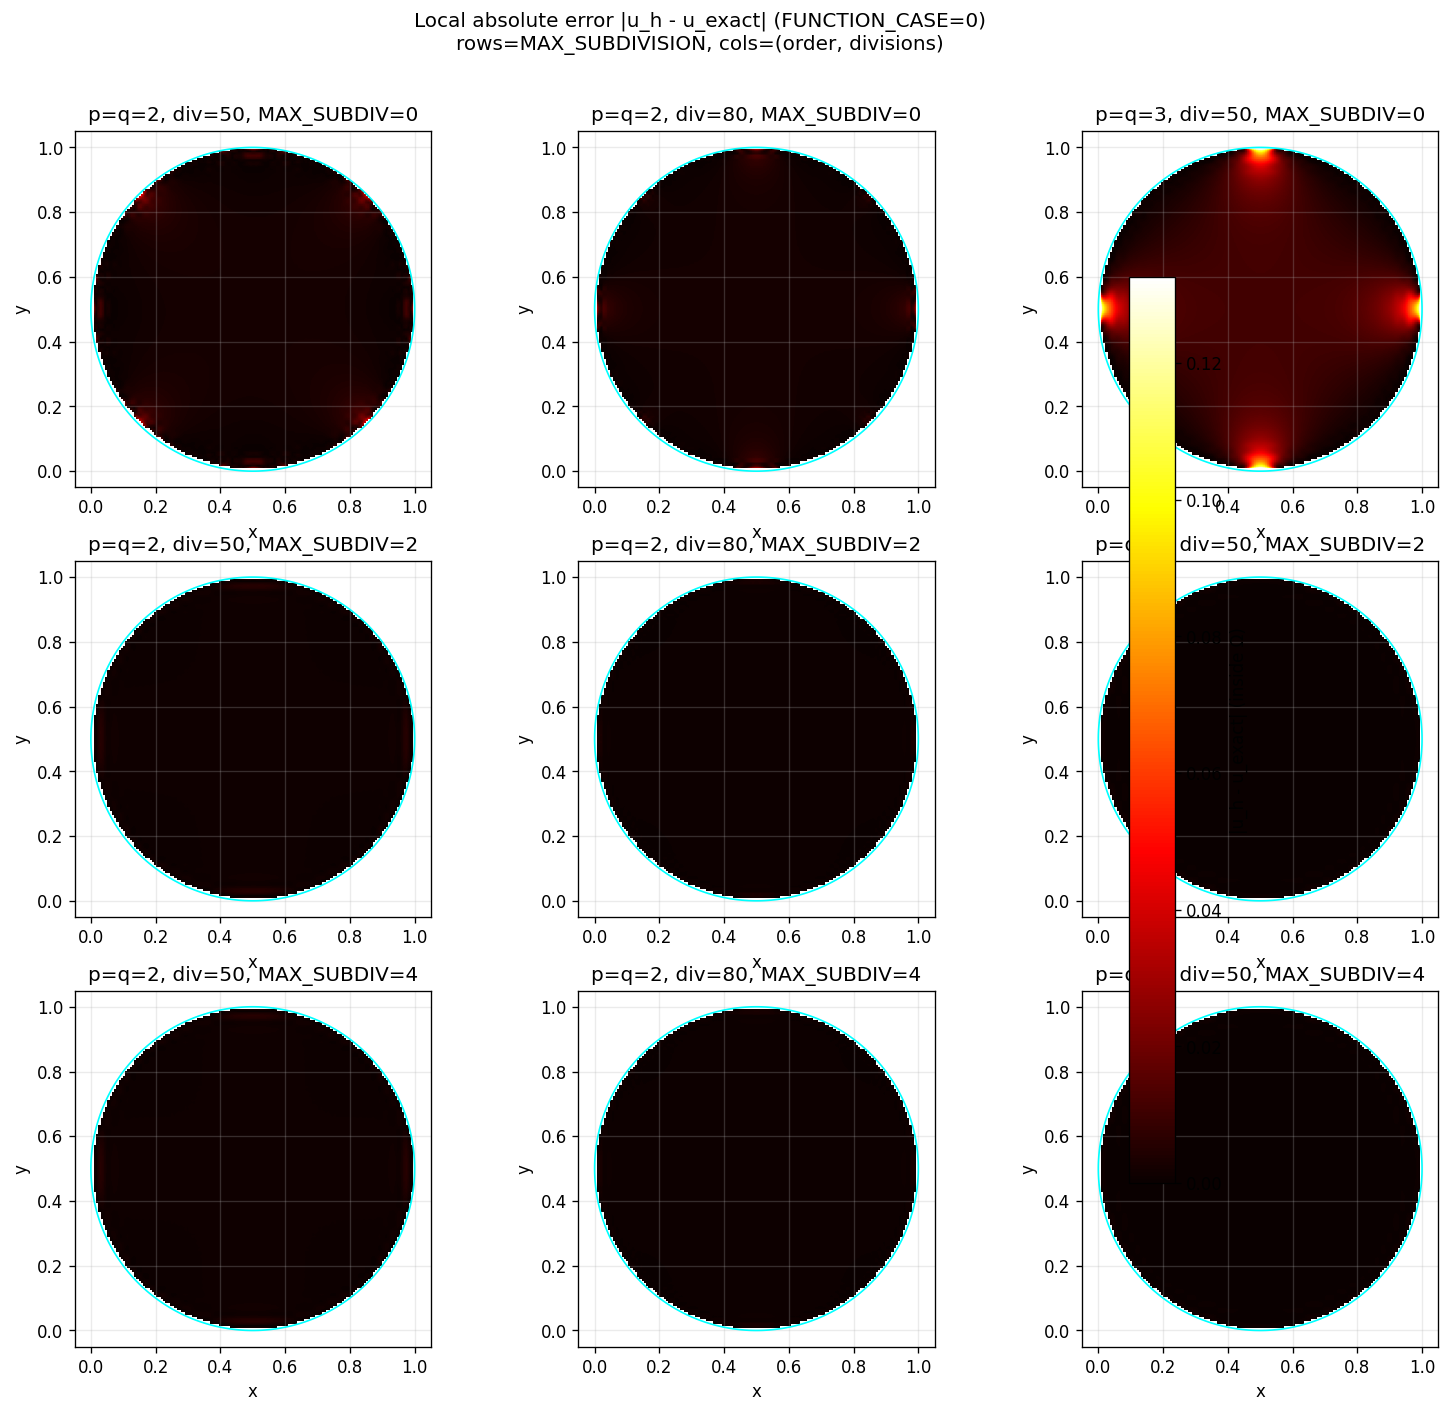

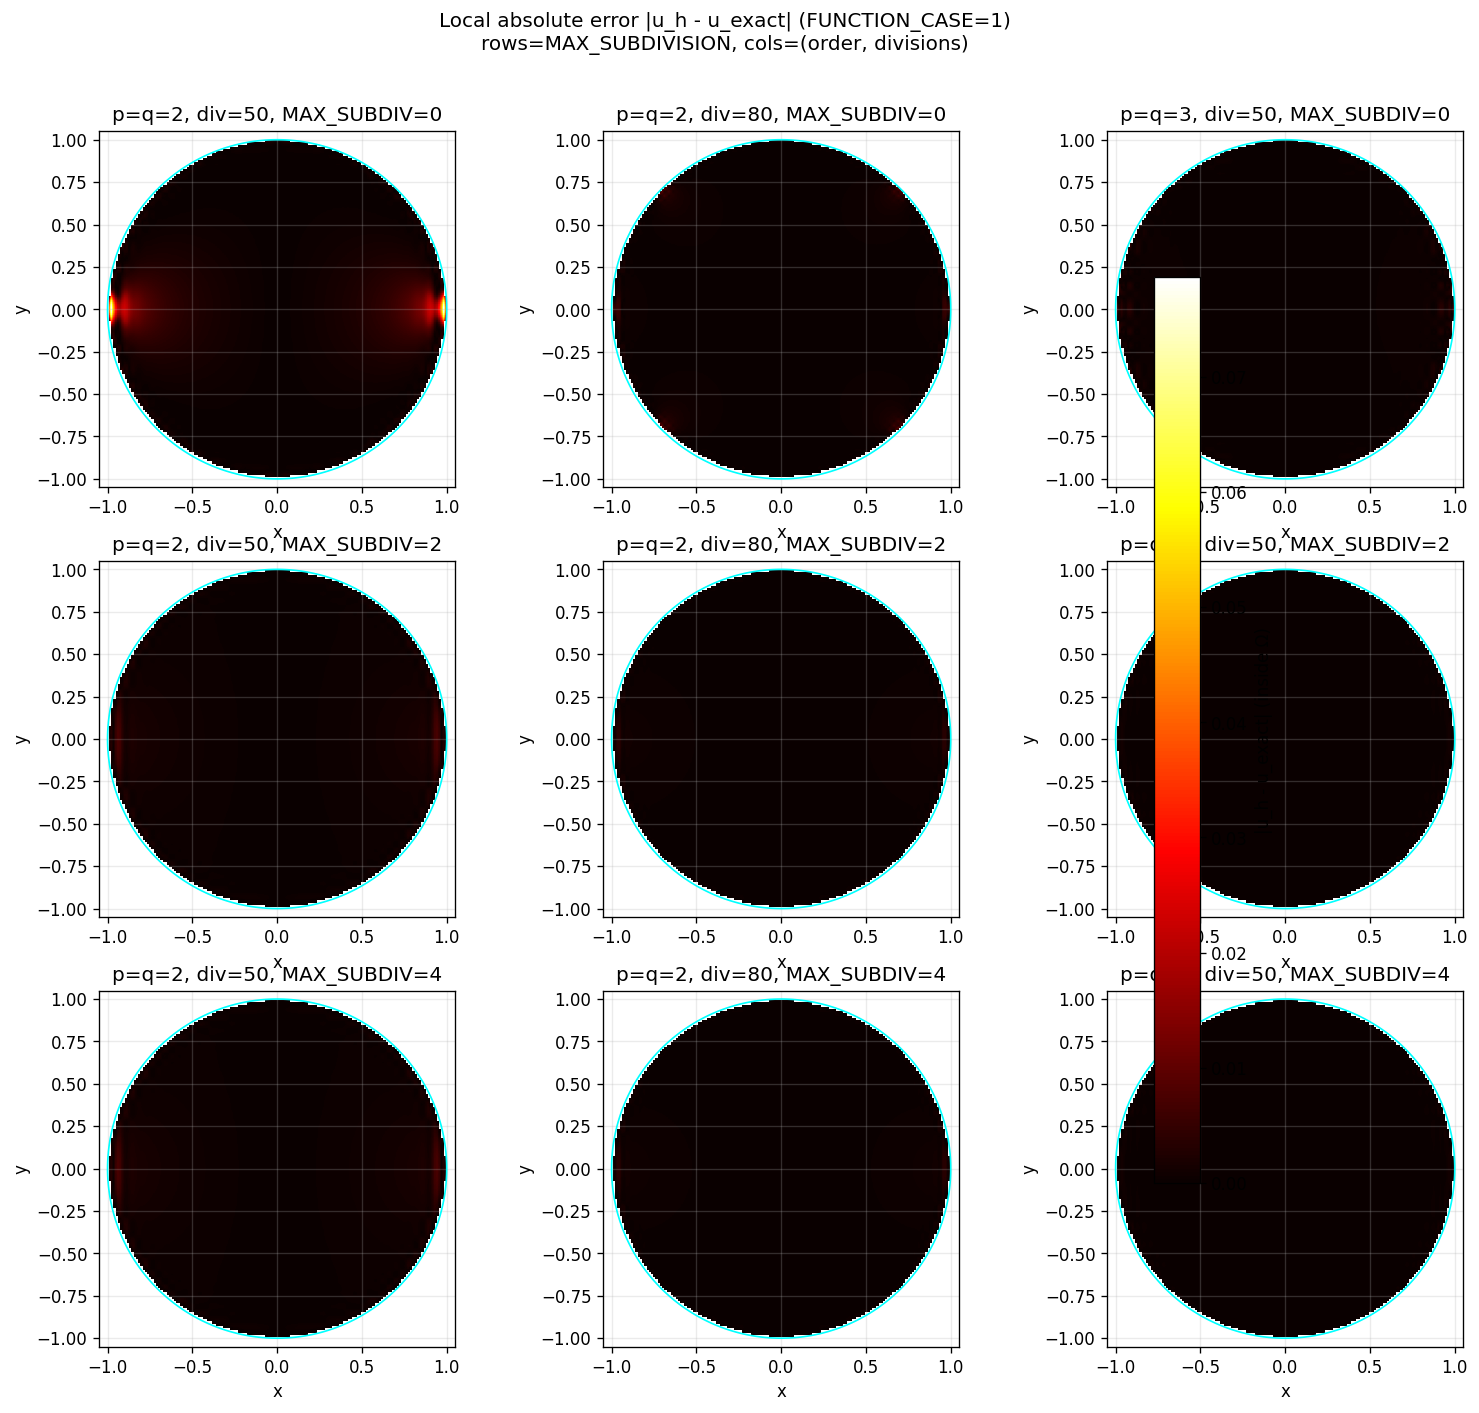

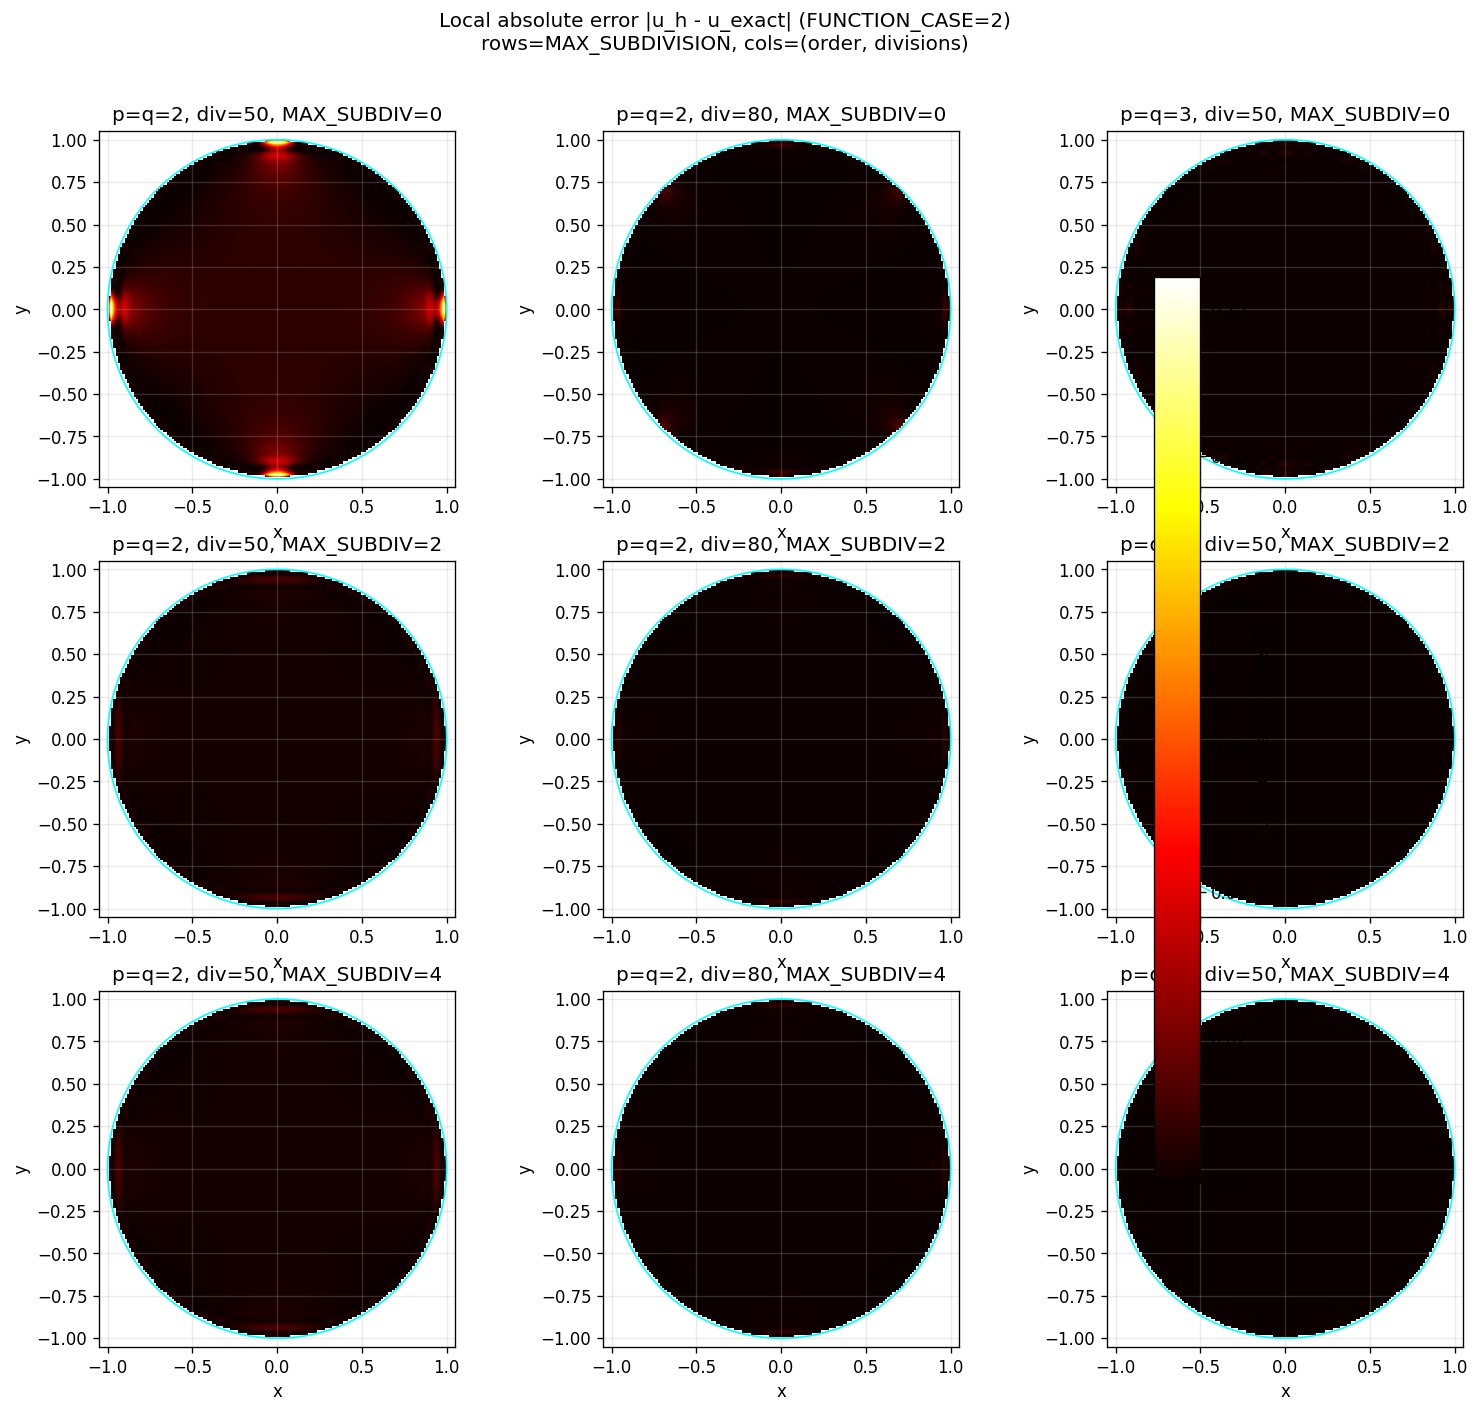

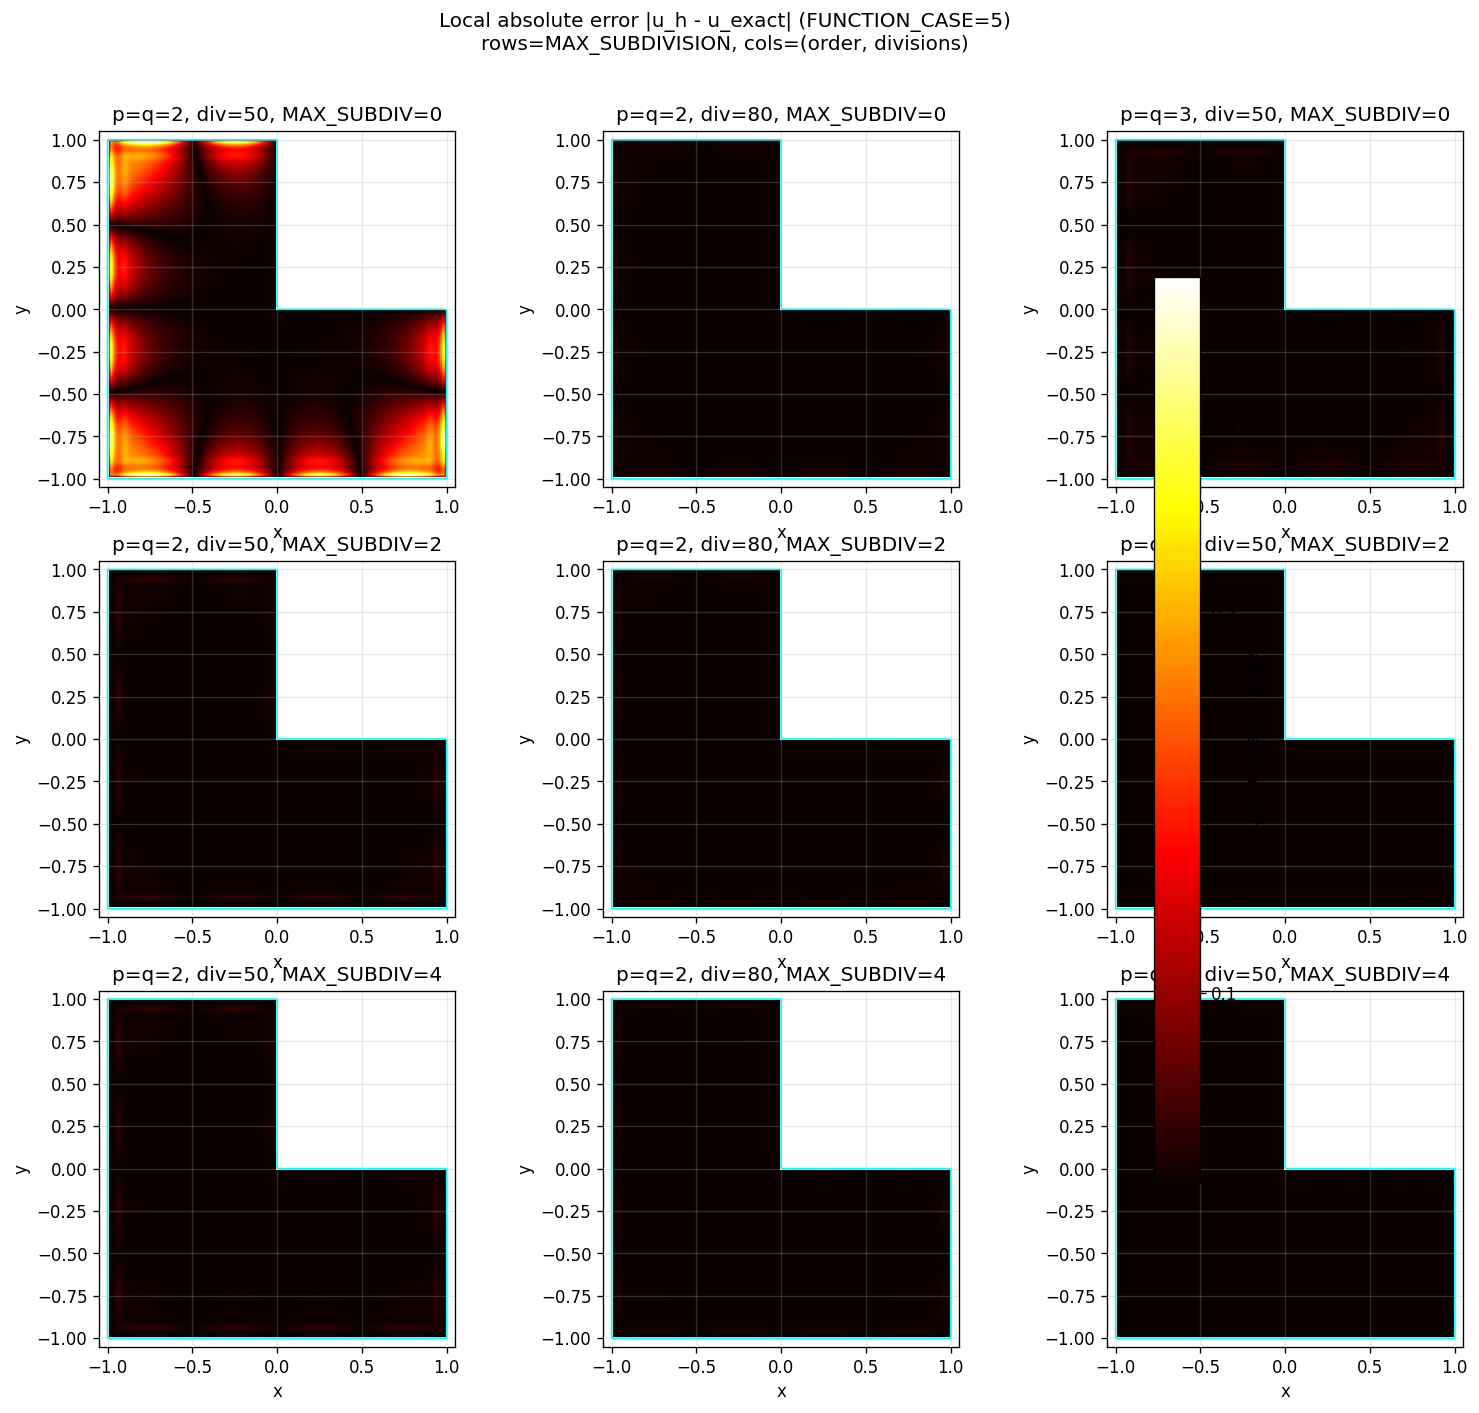

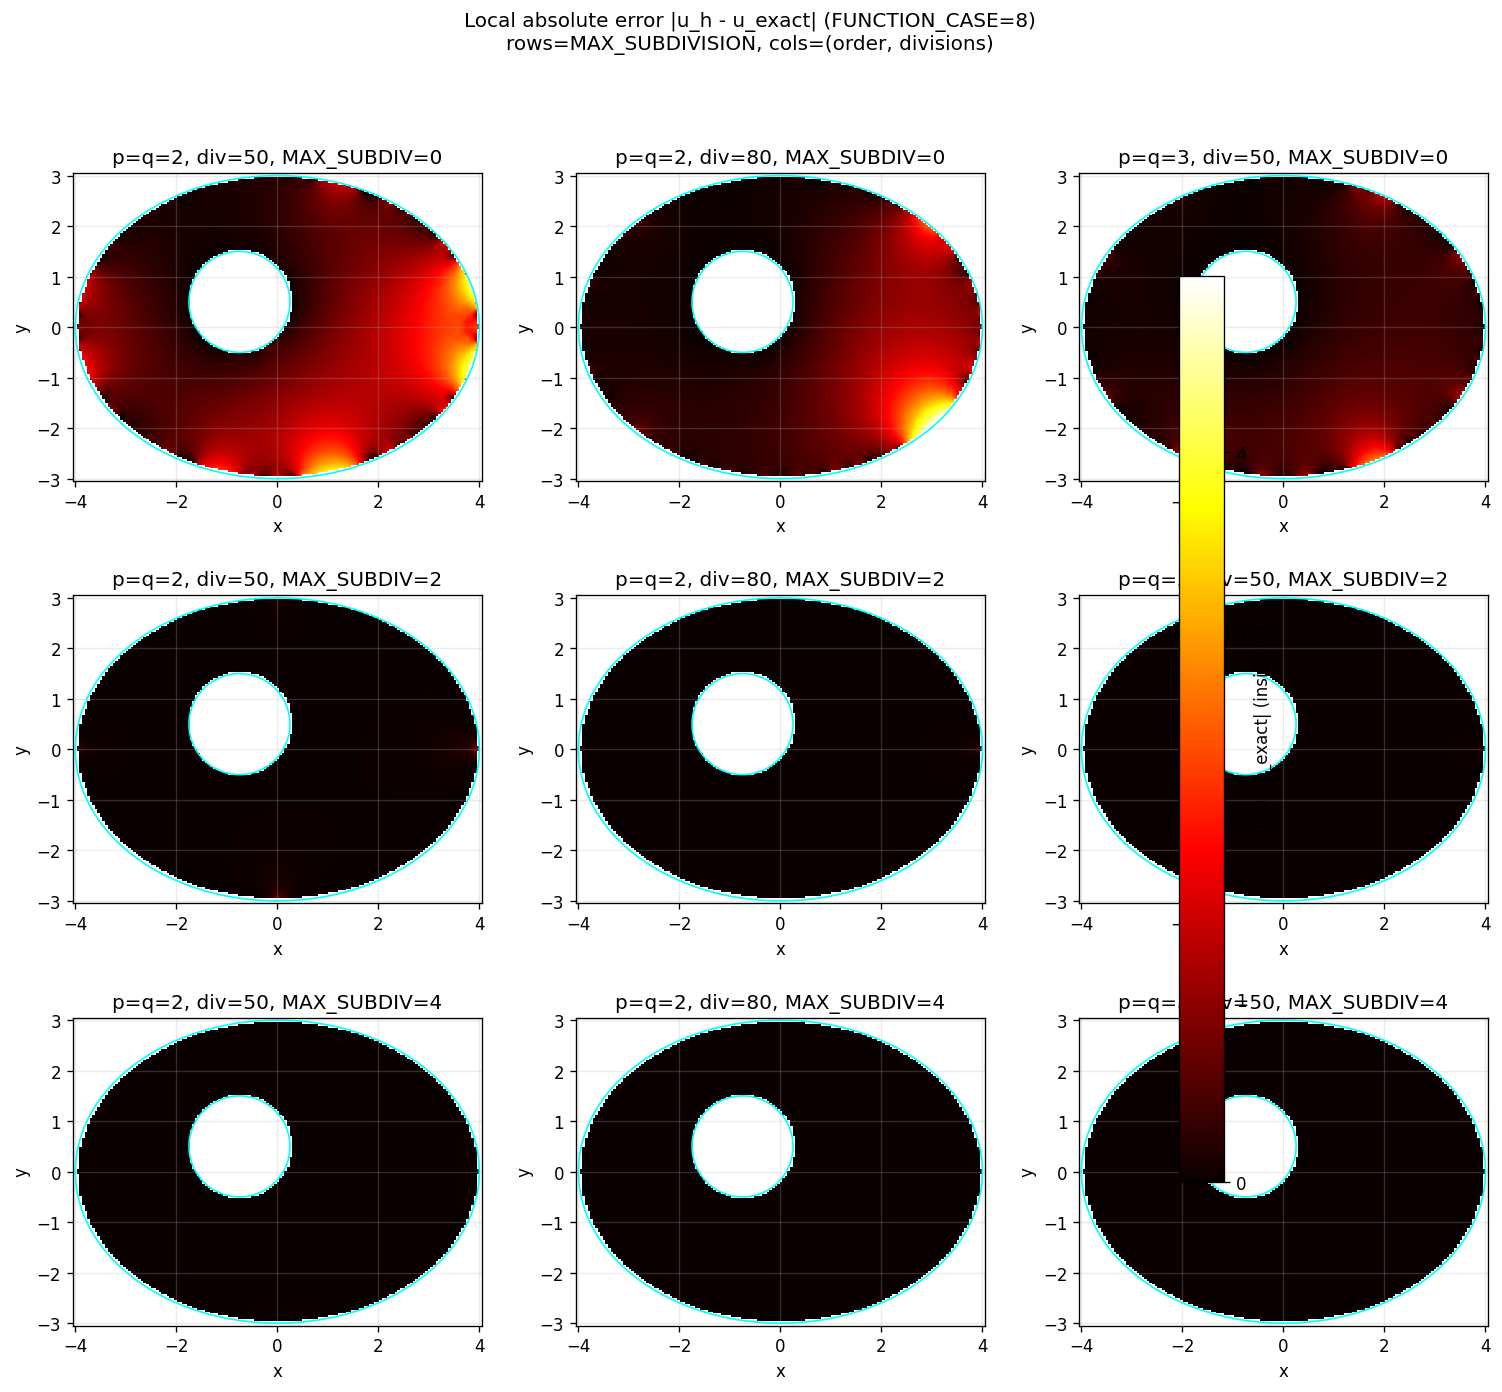

In [6]:
# --- Comparative visualization: error heatmaps (local distribution) ---

def plot_case_heatmaps(function_case: int, *, vmax=None):
    # Collect all configs for this case
    keys = [k for k in ERROR_FIELDS.keys() if k[0] == function_case]
    if not keys:
        print("No results for case", function_case)
        return

    # Sort columns by (order,div), rows by max_subdiv
    col_cfgs = sorted({(k[1], k[2]) for k in keys})  # (order,div)
    row_cfgs = sorted({k[3] for k in keys})         # max_subdiv

    # Determine color scaling per case if not provided
    if vmax is None:
        vmax = 0.0
        for k in keys:
            err = ERROR_FIELDS[k]["err_abs"]
            inside = ERROR_FIELDS[k]["inside"]
            if np.any(inside):
                vmax = max(vmax, float(np.nanmax(err)))
        if vmax <= 0:
            vmax = 1.0

    nrows = len(row_cfgs)
    ncols = len(col_cfgs)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), squeeze=False)
    fig.suptitle(f"Local absolute error |u_h - u_exact| (FUNCTION_CASE={function_case})\nrows=MAX_SUBDIVISION, cols=(order, divisions)", y=1.02)

    # Shared extent
    sample_field = ERROR_FIELDS[keys[0]]
    X = sample_field["X"]; Y = sample_field["Y"]
    extent = [float(X.min()), float(X.max()), float(Y.min()), float(Y.max())]

    for r, max_subdiv in enumerate(row_cfgs):
        for c, (order, div) in enumerate(col_cfgs):
            ax = axes[r][c]
            k = (function_case, order, div, max_subdiv)
            if k not in ERROR_FIELDS:
                ax.set_axis_off()
                continue
            field = ERROR_FIELDS[k]
            err = field["err_abs"]
            d_raw = field["d_raw"]

            im = ax.imshow(err, origin="lower", extent=extent, cmap="hot", vmin=0.0, vmax=vmax, aspect="equal")
            # Boundary overlay from raw implicit function (d_raw=0)
            try:
                ax.contour(X, Y, d_raw, levels=[0.0], colors="cyan", linewidths=1.0)
            except Exception:
                pass

            ax.set_title(f"p=q={order}, div={div}, MAX_SUBDIV={max_subdiv}")
            ax.set_xlabel("x")
            ax.set_ylabel("y")

    cbar = fig.colorbar(im, ax=axes, shrink=0.86, pad=0.02)
    cbar.set_label("|u_h - u_exact| (inside Ω)")
    plt.tight_layout()
    plt.show()


for case in CASES:
    plot_case_heatmaps(case)

,function_case,model,order,divisions,max_subdivision,t_assembly_s,t_solve_s,err_max,err_mean,err_rmse,err_q95,err_n
0,0,AnaliticalDistanceDisc_WEB,2,50,0,13.645747,0.235816,0.047343,0.002743,0.003697,0.006215,16420
1,0,AnaliticalDistanceDisc_WEB,2,50,2,27.031028,0.214066,0.005743,0.001164,0.001278,0.001732,16420
2,0,AnaliticalDistanceDisc_WEB,2,50,4,207.854351,0.188789,0.005827,0.001152,0.001271,0.001740,16420
6,0,AnaliticalDistanceDisc_WEB,2,80,0,29.260930,2.426287,0.032112,0.002195,0.002721,0.004257,16420
7,0,AnaliticalDistanceDisc_WEB,2,80,2,46.816427,2.360250,0.003292,0.000681,0.000728,0.000942,16420
8,0,AnaliticalDistanceDisc_WEB,2,80,4,341.914887,2.180934,0.003148,0.000702,0.000747,0.000982,16420
3,0,AnaliticalDistanceDisc_WEB,3,50,0,21.336388,0.194261,0.132619,0.011294,0.015572,0.025275,16420
4,0,AnaliticalDistanceDisc_WEB,3,50,2,33.680854,0.206904,0.001797,0.000415,0.000448,0.000687,16420
5,0,AnaliticalDistanceDisc_WEB,3,50,4,285.637992,0.354159,0.001780,0.000410,0.000445,0.000687,16420
9,1,AnaliticalDistanceCircle,2,50,0,11.095950,0.389800,0.078665,0.001519,0.004071,0.005459,18032


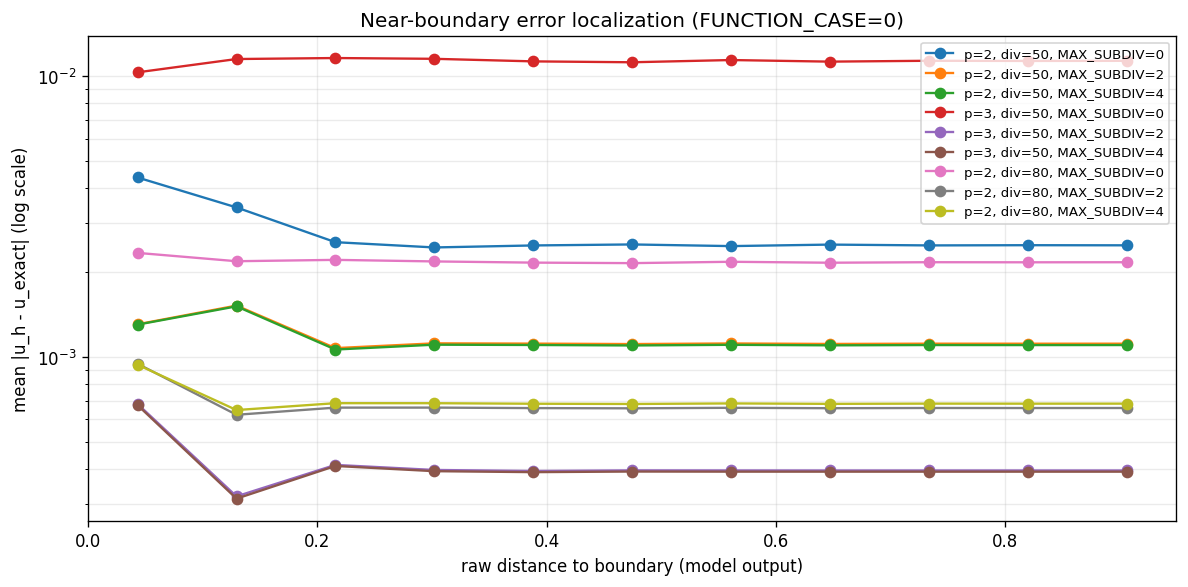

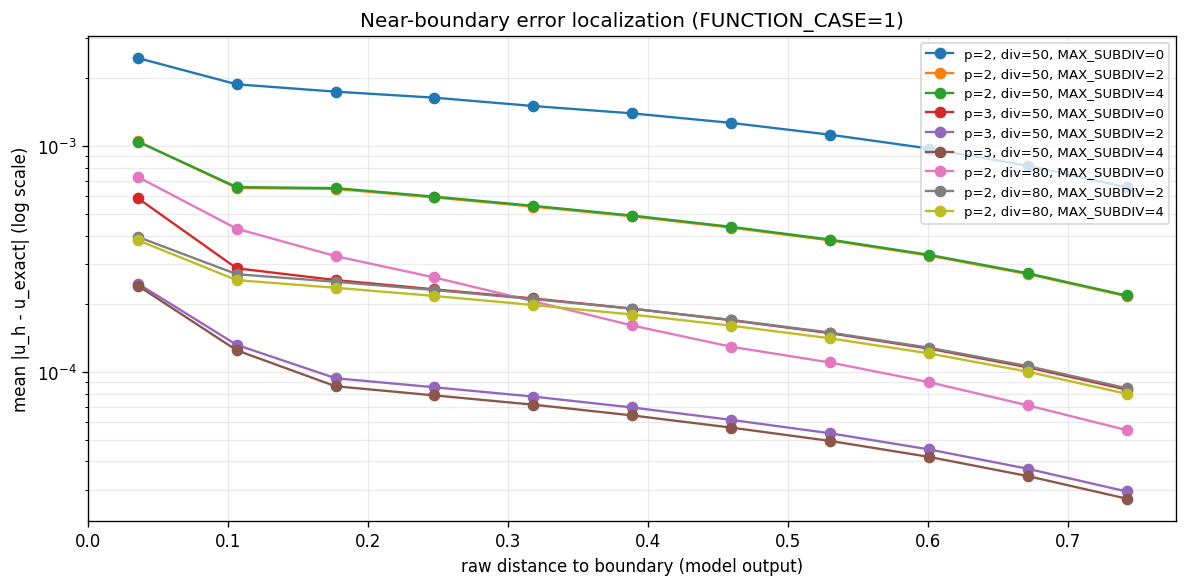

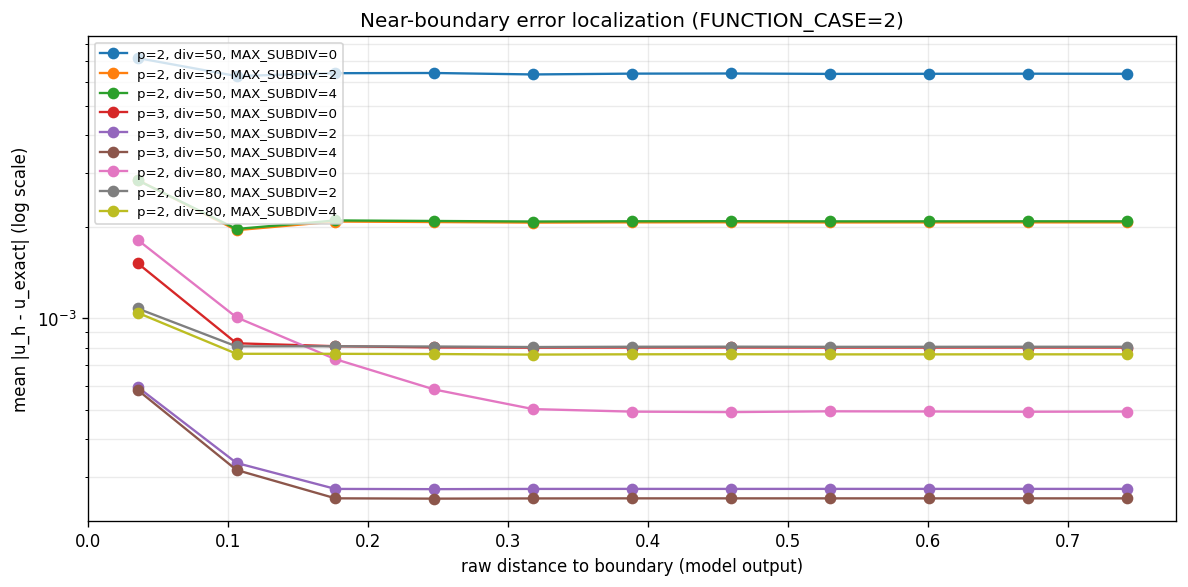

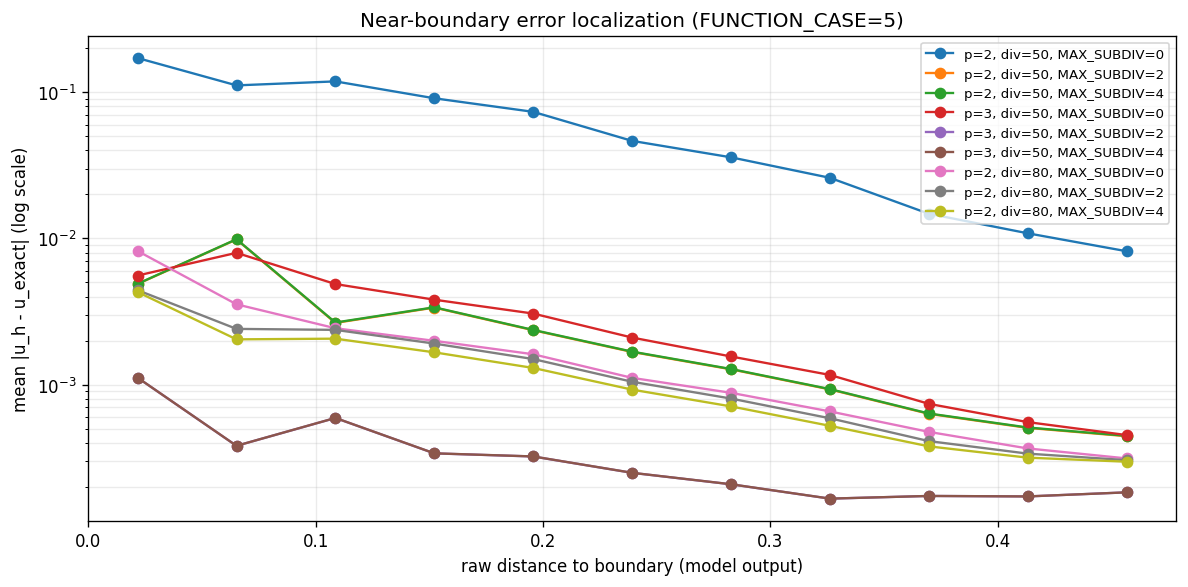

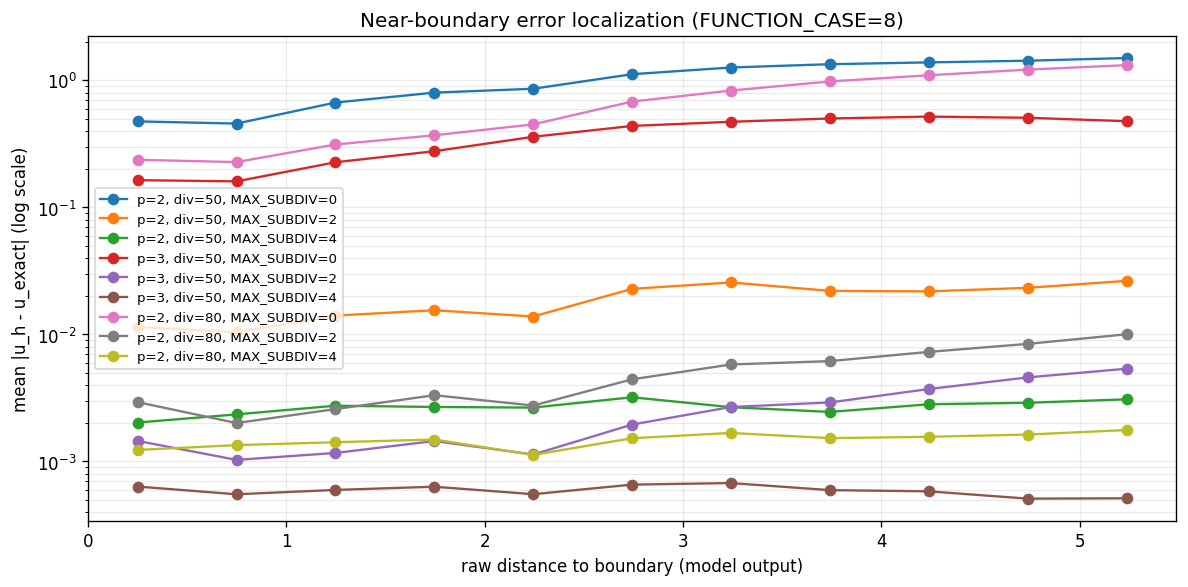

In [7]:
# --- Summary tables + near-boundary localization ---

def _try_make_dataframe(rows):
    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except Exception as e:
        print("pandas not available (ok):", e)
        return None


df = _try_make_dataframe([{k: v for k, v in r.items() if k != "bins"} for r in RESULTS])
if df is not None:
    display_cols = [
        "function_case","model","order","divisions","max_subdivision",
        "t_assembly_s","t_transform_s","t_solve_s",
        "err_max","err_mean","err_rmse","err_q95","err_n",
    ]
    # Keep only existing cols (robust to older cached runs)
    display_cols = [c for c in display_cols if c in df.columns]
    display(df[display_cols].sort_values(["function_case","order","divisions","max_subdivision"]))
else:
    # Minimal print fallback
    for r in RESULTS:
        keys = ["function_case","order","divisions","max_subdivision","t_assembly_s","t_transform_s","t_solve_s","err_max","err_mean","err_rmse"]
        print({k: r.get(k) for k in keys})


def plot_binned_error_for_case(function_case: int):
    """Plot mean error vs raw distance-to-boundary bins for each config."""
    rows = [r for r in RESULTS if r["function_case"] == function_case]
    if not rows:
        print("No results for case", function_case)
        return

    plt.figure(figsize=(10, 5))
    for r in rows:
        bins = r["bins"]
        centers = np.array([(b["d_lo"] + b["d_hi"]) * 0.5 for b in bins], dtype=float)
        means = np.array([b["mean"] for b in bins], dtype=float)
        label = f"p={r['order']}, div={r['divisions']}, MAX_SUBDIV={r['max_subdivision']}"
        plt.plot(centers, means, marker="o", linewidth=1.4, label=label)

    plt.yscale("log")
    plt.xlabel("raw distance to boundary (model output)")
    plt.ylabel("mean |u_h - u_exact| (log scale)")
    plt.title(f"Near-boundary error localization (FUNCTION_CASE={function_case})")
    plt.legend(fontsize=8)
    plt.grid(True, which="both", alpha=0.25)
    plt.tight_layout()
    plt.show()


for case in CASES:
    plot_binned_error_for_case(case)